In [13]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
edf_path = "sleepdata/SC4001E0-PSG.edf"
raw = mne.io.read_raw_edf(edf_path, preload=True)
hypnogram_file = "sleepdata/SC4001EC-Hypnogram.edf"
annot = mne.read_annotations(hypnogram_file)
raw.set_annotations(annot)

Extracting EDF parameters from C:\Users\onontsatsalg\Documents\Code\PersonalAI\sleepdata\SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_16344\2039223878.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_16344\2039223878.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_16344\2039223878.py:2: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf(edf_path, preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_16344\2039223878.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw.set_annotations(annot)


<RawEDF | SC4001E0-PSG.edf, 7 x 7950000 (79500.0 s), ~424.6 MiB, data loaded>

In [17]:
def visualize_channel(channel_name='EEG Fpz-Cz'):
    data, times = raw[channel_name]
    sfreq = raw.info['sfreq']  # Sampling frequency
    end_sample = int(60 * sfreq)
    data_60s = data[0][:end_sample]
    times_60s = times[:end_sample]
    
    # Create a line plot using seaborn
    sns.set(style="whitegrid")
    plt.figure(figsize=(12, 4))
    sns.lineplot(x=times_60s, y=data_60s)
    plt.title(f"Signal from Channel: {channel_name} (First 60 seconds)")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude (µV)")
    plt.tight_layout()
    plt.show()

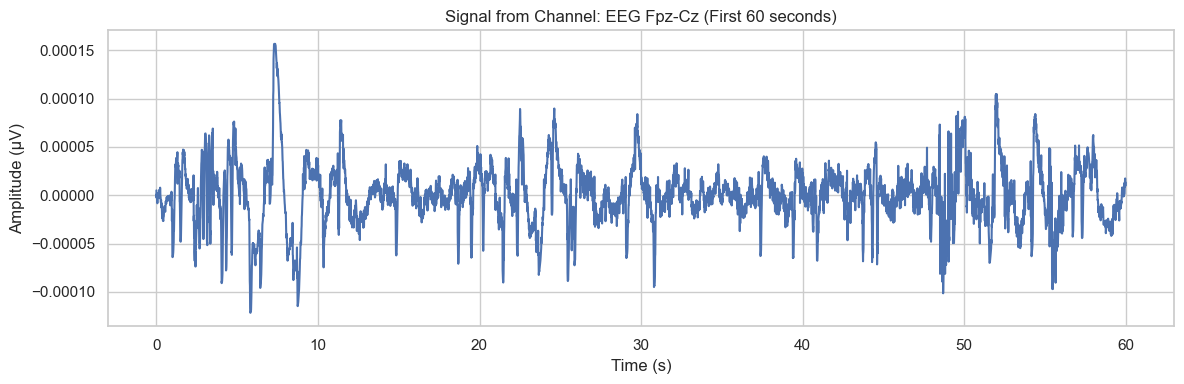

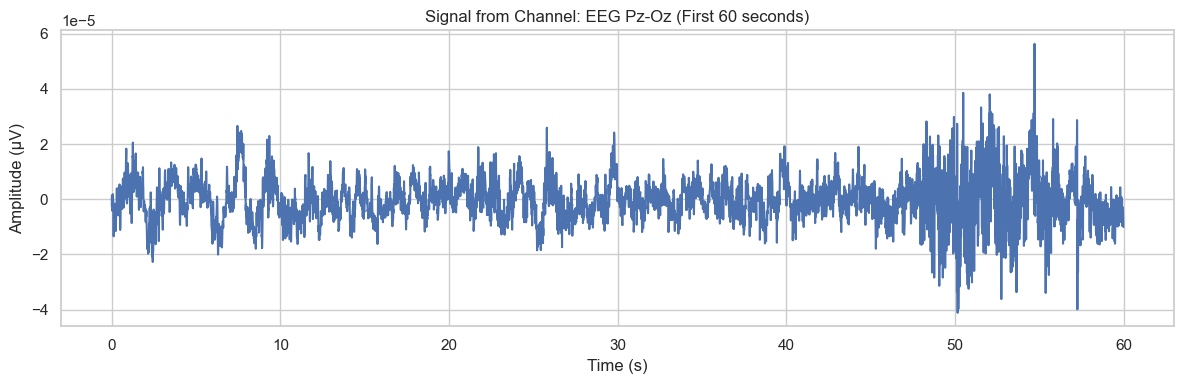

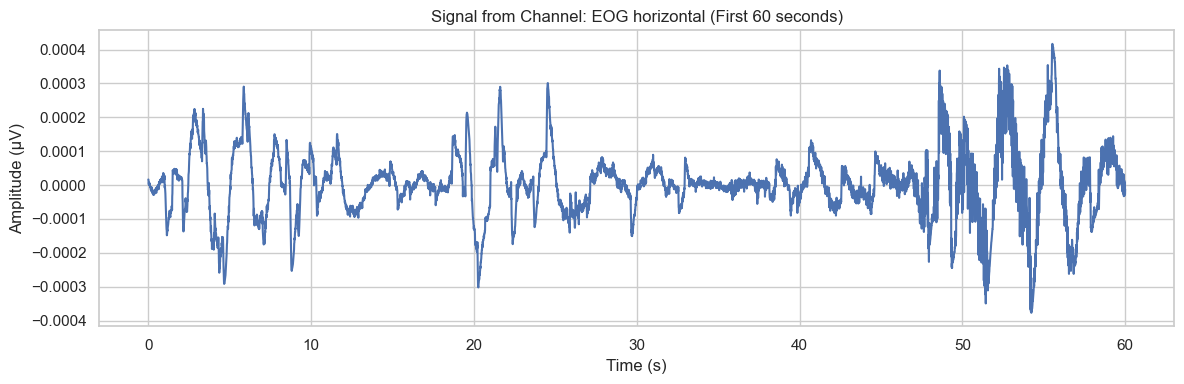

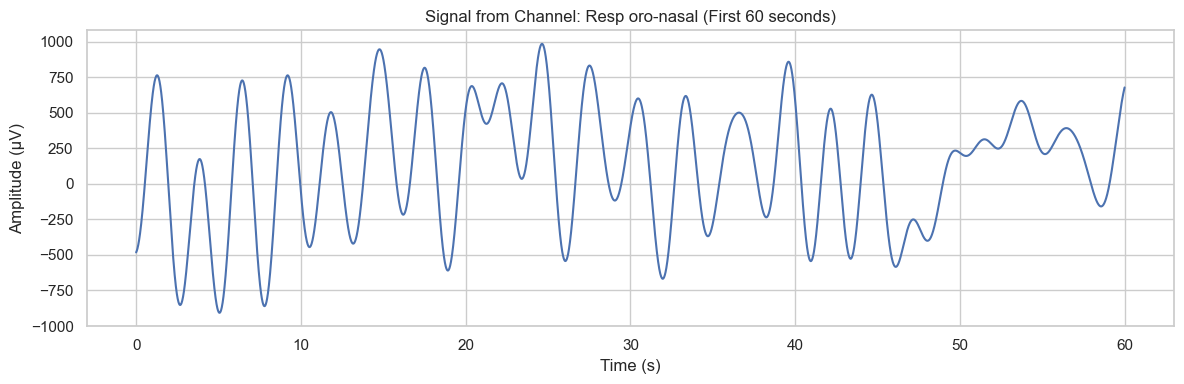

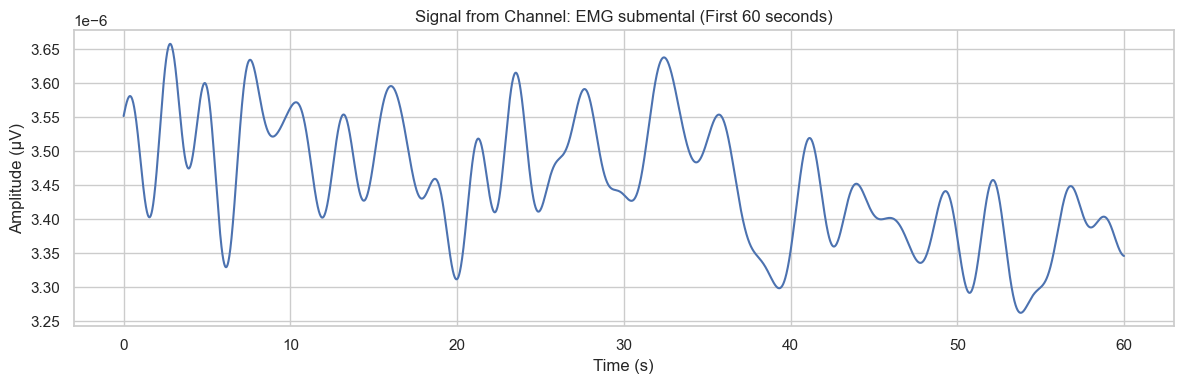

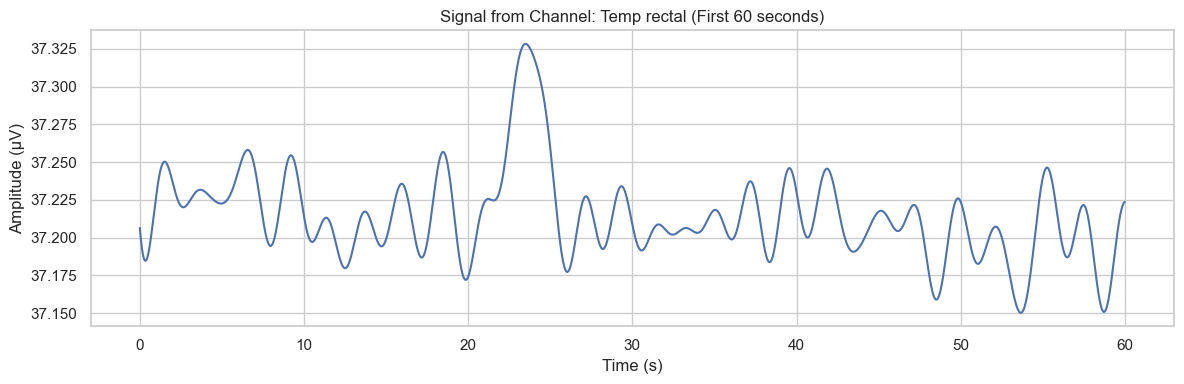

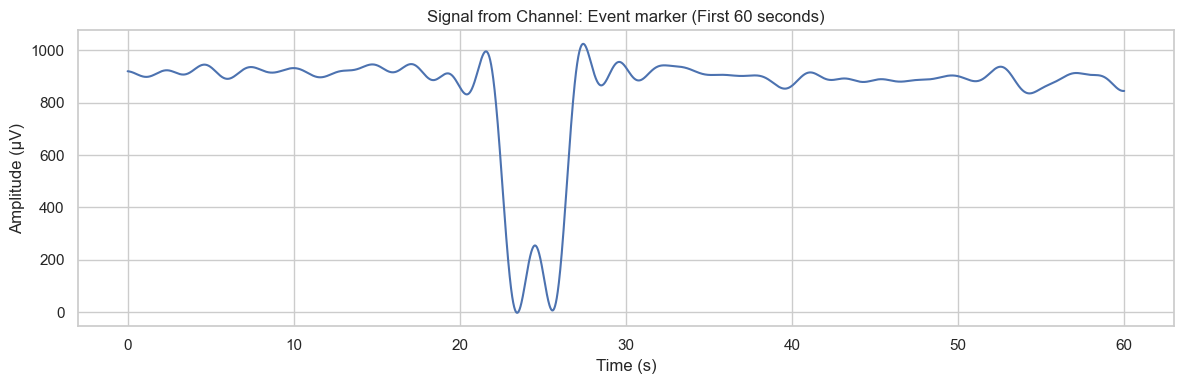

In [18]:
for channl in raw.ch_names:
    visualize_channel(channl)

### Power Spectral Density (PSD) of EEG Channels

Extracting EDF parameters from C:\Users\onontsatsalg\Documents\Code\PersonalAI\sleepdata\SC4001E0-PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7949999  =      0.000 ... 79499.990 secs...


C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_16344\2144915777.py:1: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf("sleepdata/SC4001E0-PSG.edf", preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_16344\2144915777.py:1: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf("sleepdata/SC4001E0-PSG.edf", preload=True)
C:\Users\onontsatsalg\AppData\Local\Temp\ipykernel_16344\2144915777.py:1: RuntimeWarning: Highpass cutoff frequency 16.0 is greater than lowpass cutoff frequency 0.7, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_edf("sleepdata/SC4001E0-PSG.edf", preload=True)


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 20.480 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 20.480 (s)
Plotting power spectral density (dB=True).


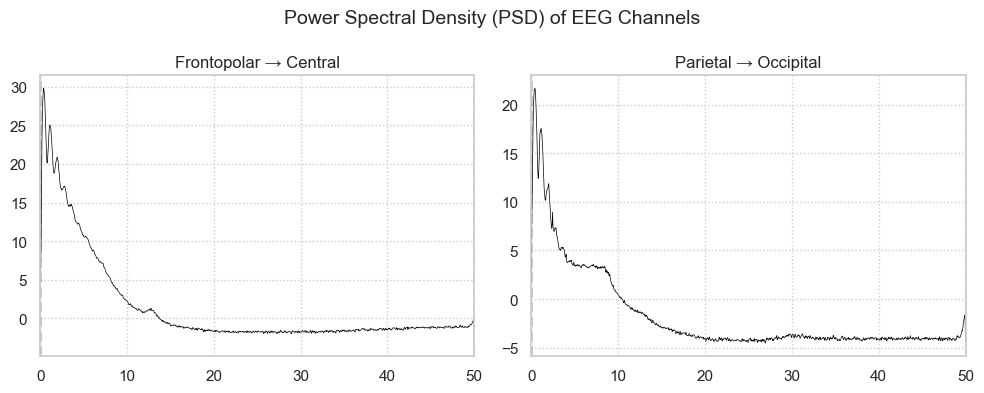

In [19]:
raw = mne.io.read_raw_edf("sleepdata/SC4001E0-PSG.edf", preload=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle(f'Power Spectral Density (PSD) of EEG Channels', fontsize=14)

# Plot PSD before filtering
raw.plot_psd(picks='EEG Fpz-Cz', ax=axes[0], average=True, show=False)
axes[0].set_title('Frontopolar → Central')

# Plot PSD after filtering
raw.plot_psd(picks='EEG Pz-Oz', ax=axes[1], average=True, show=False)
axes[1].set_title('Parietal → Occipital')

plt.tight_layout()
plt.show()